# FoodChain AI
## Exploratory Data Analysis (EDA)

**Objective:** Understand and validate the supplier dataset before feature engineering and K-Means clustering.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Load Dataset

In [2]:
df = pd.read_csv('../data/pune_supplier_dataset.csv')

## First Look

In [3]:
df.head()

,supplier_id,supplier_name,supplier_type,market,area,latitude,longitude,ingredient,category,price,unit,stock_available,minimum_order,quality_score,rating,reliability_score,delivery_radius_km,average_delivery_time_min
0,SUP00001,Saraswati Masala Bhandar,Spice Supplier,Kharadi,Kharadi,18.559272,73.961276,Garam Masala,Spice,334.36,kg,491,50,3.6,3.6,71.5,7.9,46
1,SUP00001,Saraswati Masala Bhandar,Spice Supplier,Kharadi,Kharadi,18.559272,73.961276,Red Chilli Powder,Spice,220.03,kg,807,50,3.6,3.6,71.5,7.9,46
2,SUP00001,Saraswati Masala Bhandar,Spice Supplier,Kharadi,Kharadi,18.559272,73.961276,Turmeric,Spice,198.57,kg,335,5,3.6,3.6,71.5,7.9,46
3,SUP00001,Saraswati Masala Bhandar,Spice Supplier,Kharadi,Kharadi,18.559272,73.961276,Mustard Seeds,Spice,110.54,kg,933,50,3.6,3.6,71.5,7.9,46
4,SUP00001,Saraswati Masala Bhandar,Spice Supplier,Kharadi,Kharadi,18.559272,73.961276,Coriander Powder,Spice,170.32,kg,550,50,3.6,3.6,71.5,7.9,46


## Dataset Overview

In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16530 entries, 0 to 16529
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   supplier_id                16530 non-null  object 
 1   supplier_name              16530 non-null  object 
 2   supplier_type              16530 non-null  object 
 3   market                     16530 non-null  object 
 4   area                       16530 non-null  object 
 5   latitude                   16530 non-null  float64
 6   longitude                  16530 non-null  float64
 7   ingredient                 16530 non-null  object 
 8   category                   16530 non-null  object 
 9   price                      16530 non-null  float64
 10  unit                       16530 non-null  object 
 11  stock_available            16530 non-null  int64  
 12  minimum_order              16530 non-null  int64  
 13  quality_score              16530 non-null  flo

## Missing Values & Duplicates

In [5]:
df.isnull().sum()

,0
supplier_id,0
supplier_name,0
supplier_type,0
market,0
area,0
latitude,0
longitude,0
ingredient,0
category,0
price,0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

## Statistical Summary

In [6]:
df.describe()

,latitude,longitude,price,stock_available,minimum_order,quality_score,rating,reliability_score,delivery_radius_km,average_delivery_time_min
count,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000,16530.000000
mean,18.527862,73.851477,145.359765,2054.577919,35.363581,4.157260,4.151912,85.761476,7.781603,32.486691
std,0.047432,0.053997,153.575614,2001.531967,68.528683,0.359221,0.355652,6.901877,2.918304,11.471307
min,18.419561,73.703844,3.030000,51.000000,5.000000,3.500000,3.500000,70.000000,2.000000,10.000000
25%,18.493915,73.808969,42.280000,683.000000,10.000000,3.900000,3.900000,81.400000,5.500000,23.000000
50%,18.515905,73.858146,74.230000,1474.000000,20.000000,4.100000,4.100000,85.600000,7.800000,32.000000
75%,18.563860,73.883921,193.567500,2746.500000,50.000000,4.400000,4.400000,90.800000,9.900000,41.000000
max,18.660159,73.974589,649.760000,15988.000000,500.000000,5.000000,5.000000,100.000000,15.000000,60.000000


## Unique Values

In [7]:
for col in df.columns:
    print(col, df[col].nunique())

supplier_id 3700
supplier_name 3700
supplier_type 6
market 20
area 20
latitude 3657
longitude 3660
ingredient 33
category 6
price 11687
unit 3
stock_available 5216
minimum_order 8
quality_score 16
rating 16
reliability_score 301
delivery_radius_km 131
average_delivery_time_min 51


## Numerical Feature Analysis

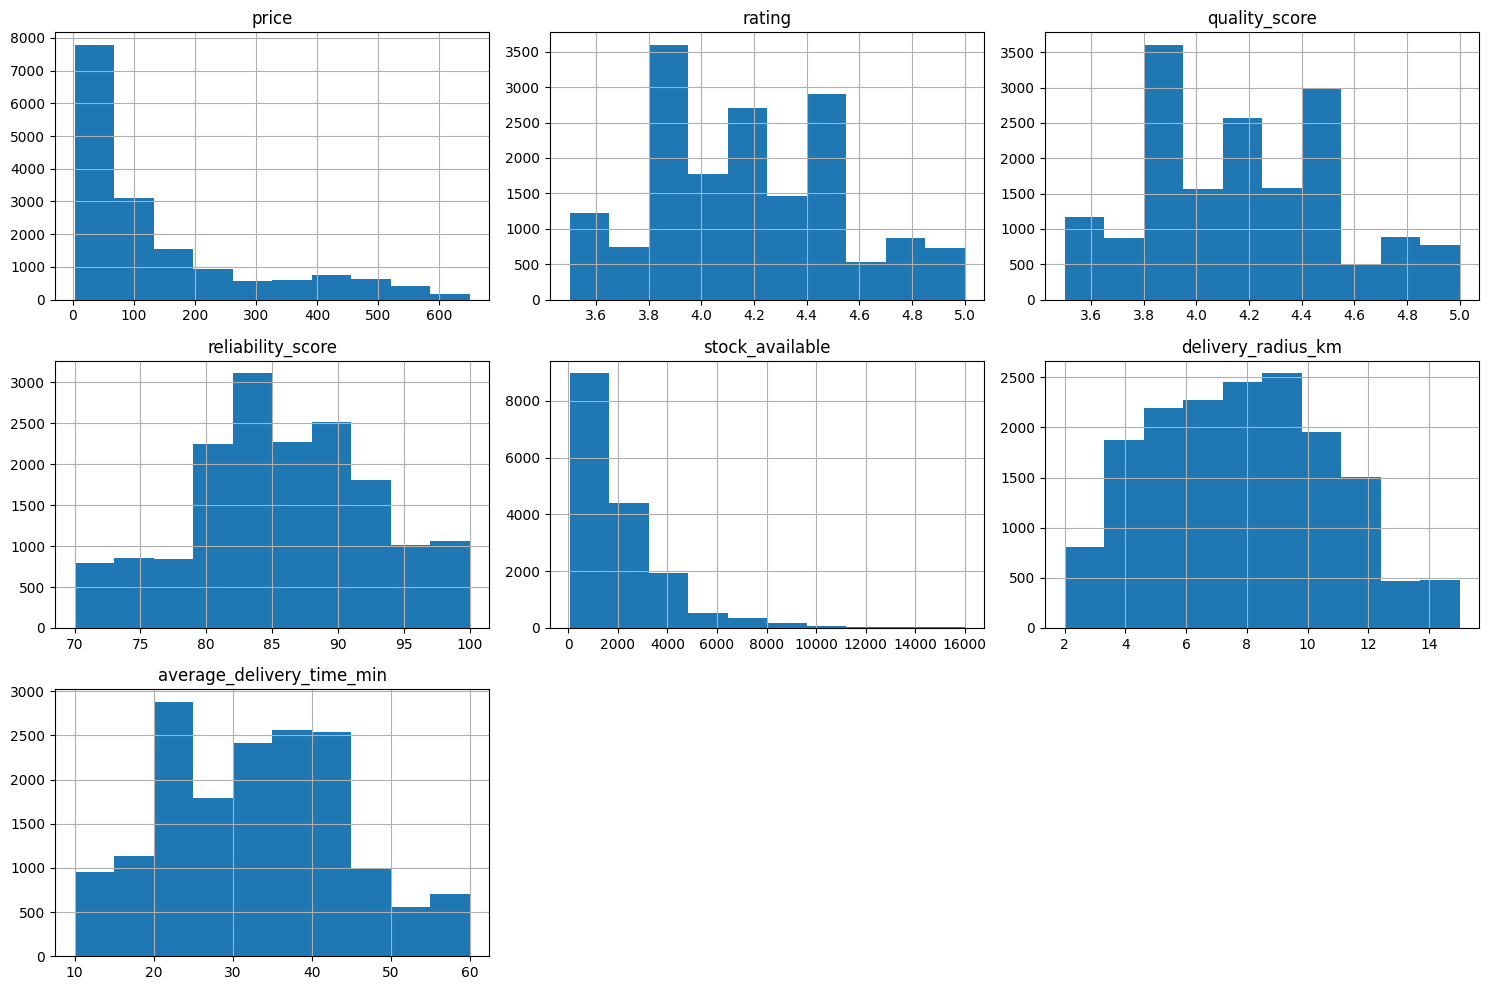

In [8]:
num_cols = [
    "price",
    "rating",
    "quality_score",
    "reliability_score",
    "stock_available",
    "delivery_radius_km",
    "average_delivery_time_min"
]

df[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3,3, figsize=(15,10))
axes=axes.flatten()
for i,col in enumerate(num_cols):
    import seaborn as sns
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()

## Categorical Feature Analysis

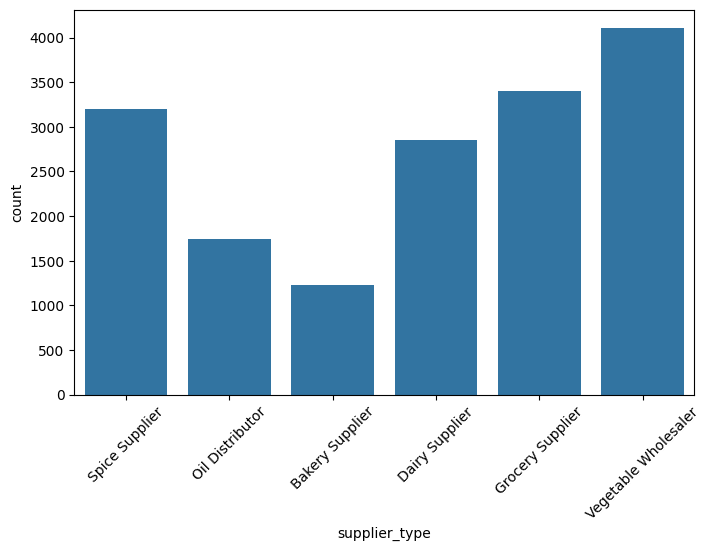

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="supplier_type")

plt.xticks(rotation=45)

plt.show()

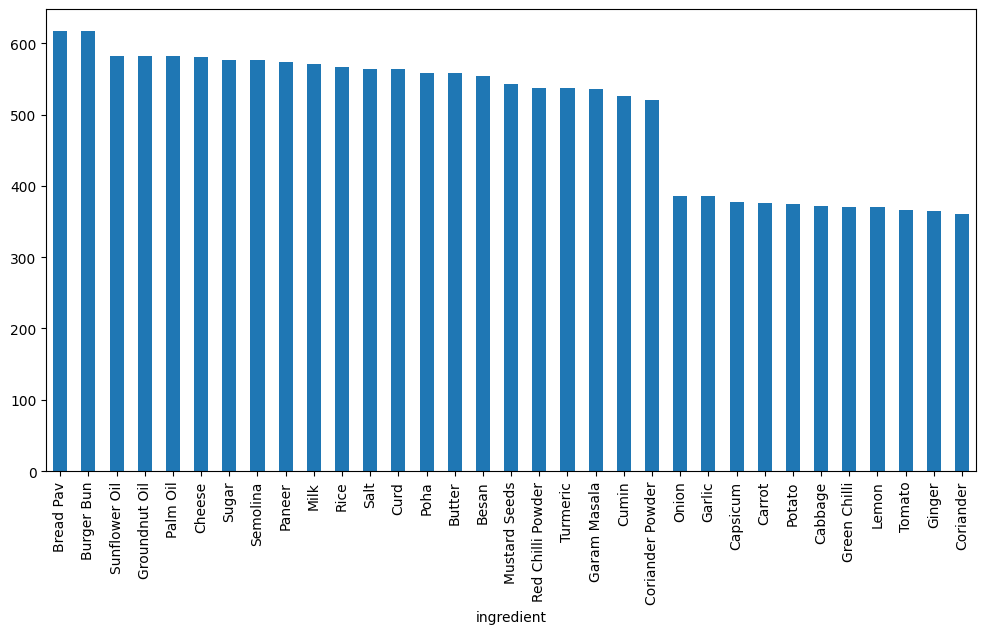

In [12]:
plt.figure(figsize=(12,6))

df["ingredient"].value_counts().plot(kind="bar")

plt.xticks(rotation=90)

plt.show()

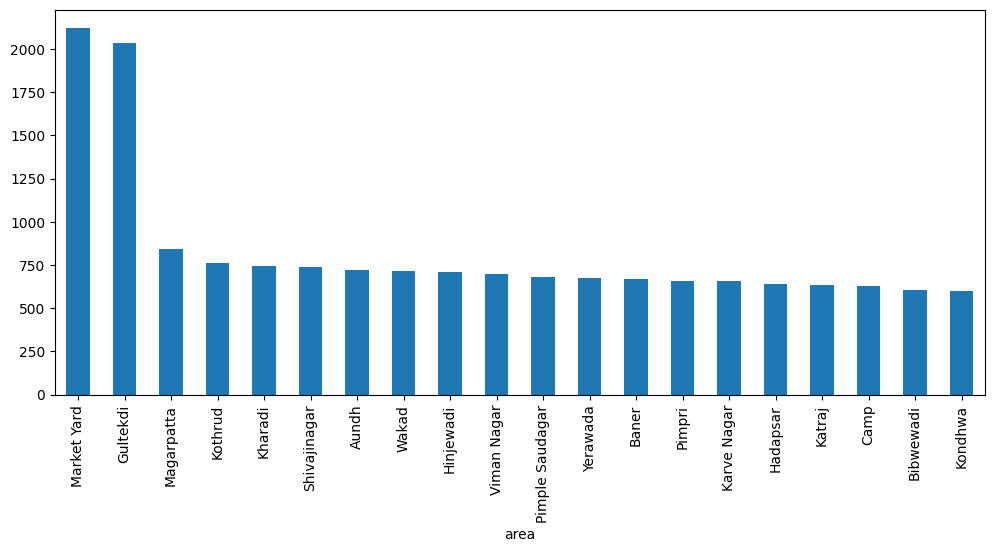

In [13]:
plt.figure(figsize=(12,5))

df["area"].value_counts().plot(kind="bar")

plt.xticks(rotation=90)

plt.show()

## Supplier Distribution Across Pune

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(df["longitude"], df["latitude"], s=3, alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Supplier Distribution Across Pune")
plt.grid(True)
plt.show()

## Correlation Analysis

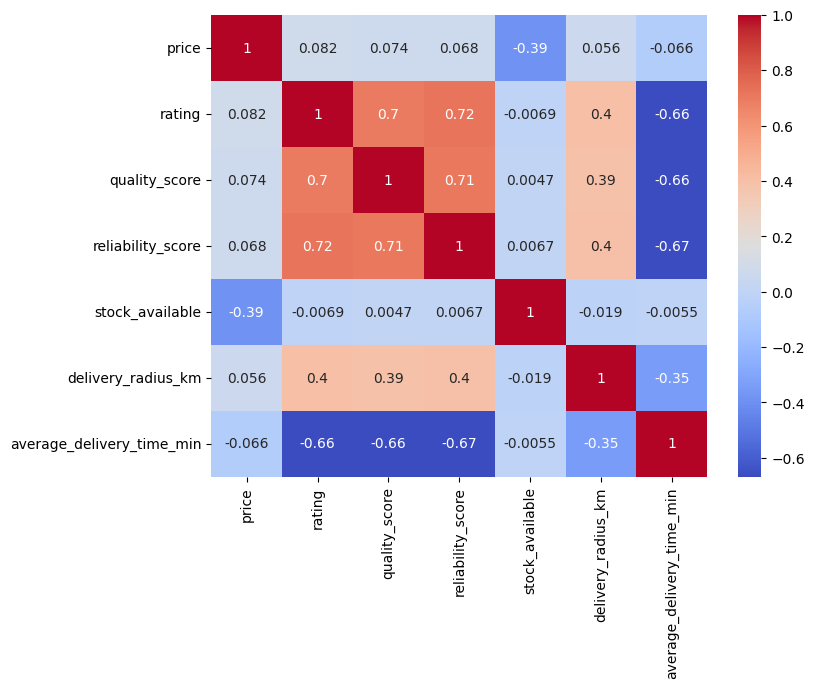

In [14]:
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.show()

## Business Validation

In [15]:
df[df["supplier_type"]=="Vegetable Wholesaler"]["category"].value_counts()

,count
category,
Vegetable,4106


In [16]:
df[df["supplier_type"]=="Dairy Supplier"]["category"].value_counts()

,count
category,
Dairy,2847


In [ ]:
print("Unique Suppliers:", df["supplier_id"].nunique())
print("Unique Ingredients:", df["ingredient"].nunique())
print("
Market Distribution:
")
print(df["market"].value_counts())

print("
Average Price by Ingredient:
")
print(df.groupby("ingredient")["price"].mean().sort_values())

print("
Supplier Type vs Category:
")
print(df.groupby("supplier_type")["category"].unique())

print("
Area vs Supplier Type:
")
print(pd.crosstab(df["area"], df["supplier_type"]))

# Key Observations

- Dataset is checked for missing values and duplicates.
- Supplier coordinates lie within Pune city limits.
- Supplier distribution reflects major wholesale markets.
- Price ranges appear realistic across ingredients.
- Ratings, quality scores and reliability are within expected business ranges.
- Dataset is suitable for feature engineering and K-Means based supplier segmentation.